# Combined VLE + SEC Constant Feed IFT Notebook
This notebook combines:
1. **VLE_IFT_constant_feed**: cDFT-based IFT across the PT phase space (isothermal pressure sweeps)
2. **SEC_MULIT**: Semi-empirical correlation IFT colormaps (Parachor T-dependent & WSD)

All results are plotted as PT colormaps for comparison.

In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import feos
import si_units as si
import numpy as np
import importlib.metadata
from pathlib import Path
import matplotlib.pyplot as plt

from thermoift import KIJ
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine,
    PARAMETERS,
)
import thermoift.semi_emperical_correlations as SEC
from thermoift.semi_emperical_correlations import semi_emperical_correlations
from thermoift.semi_emperical_correlations import ColormapDifference
import thermoift.PLOT_SETTINGS as ps

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=52af3458a99106cbb70175656c195201211a672cb56d3465902095ff293d9d05
  Stored in directory: /tmp/pip-ephem-wheel-cache-cpcnpu76/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.
FEOS version used: 0.9.4


## Configuration


K(300.0 K) =
[[0.         0.         0.03481295]
 [0.         0.         0.        ]
 [0.03481295 0.         0.        ]]

Symbolic K(T) matrix:


Matrix([
[     0, 0, 0.0348],
[     0, 0,      0],
[0.0348, 0,      0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0)

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0200       0.0300


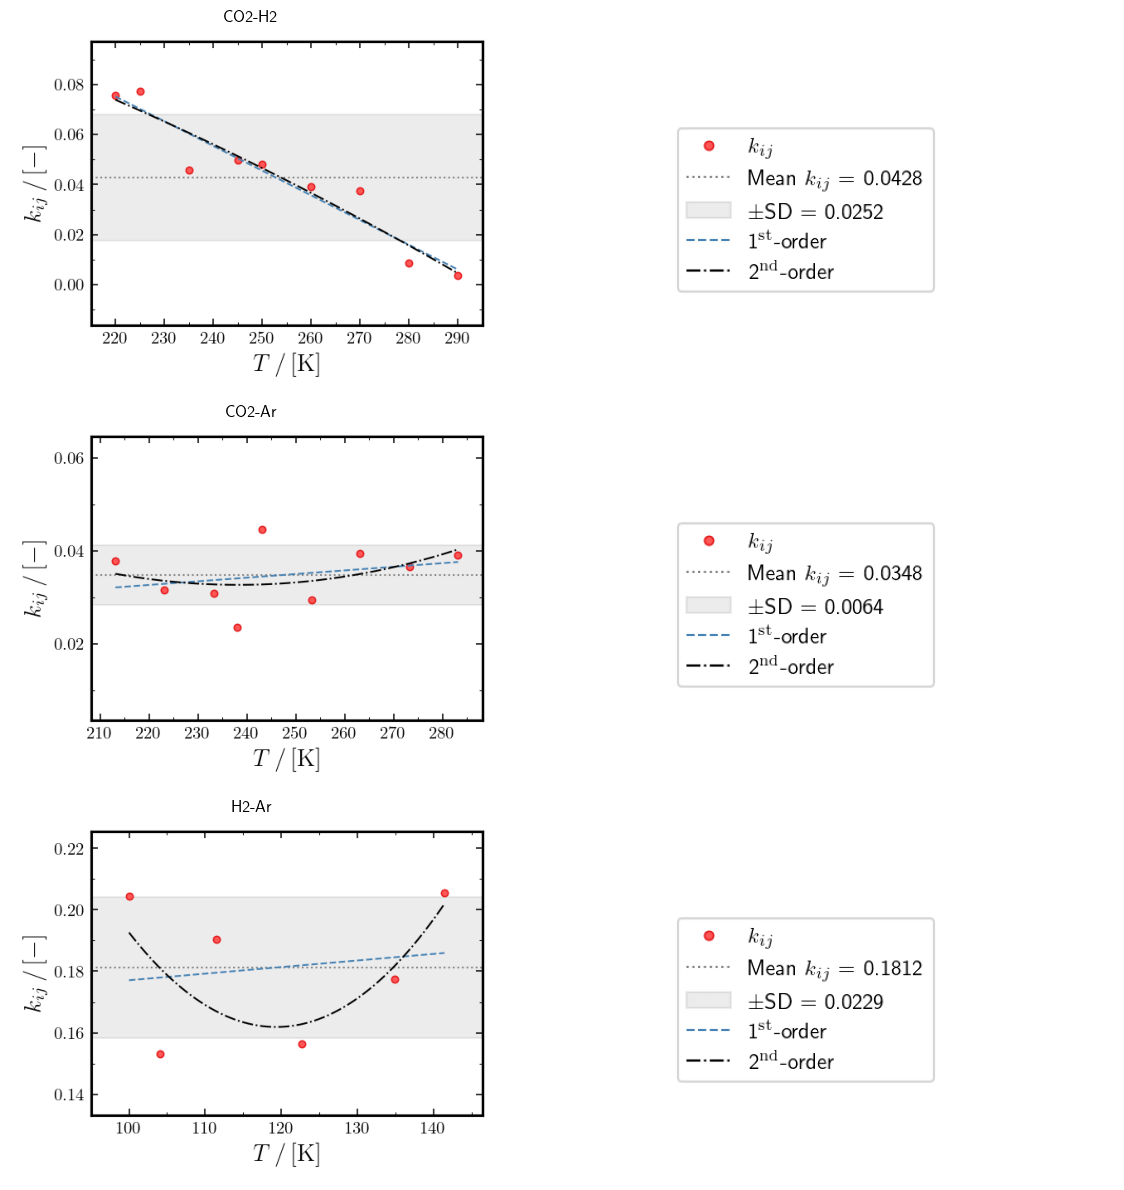

In [2]:
# --- Component & Feed Setup ---
COMPONENTS      = ["carbon dioxide", "hydrogen", "argon"]
ALL_COMPONENTS  = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

KIJ_map = {
    ("CO2", "Ar") : "constant",
    ("H2",  "Ar") : "zero",
    ("CO2", "H2") : "zero",
}

CO2_comp = 0.95
feeds    = CompositionHandler.make_feeds([CO2_comp, 0.02, 0.03])

# --- Computation settings ---
T_initial_guess = 200
T_STEP          = 5        # Temperature step for phase envelope [K] (fine for accurate curves)
P_TOL           = 1e-4     # Pressure tolerance for flash [bar]
lgrid           = 100      # cDFT domain length [Angstrom]
ngrid           = 2048     # cDFT grid points
verbose         = False

# --- Shared resolution for cDFT and SEC colormaps ---
N_T = 10               # Number of temperature points in PT sweep
N_P = 10               # Number of pressure points per isotherm
                        # Grid size: 30 x 30 = 900 points max

CSV_FOLDER = "CSV_combined_constant_feed"
Path(CSV_FOLDER).mkdir(parents=True, exist_ok=True)

# --- KIJ builder & display ---
builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
parameters = PARAMETERS(COMPONENTS, T_K=300.0, kij_builder=builder, model_map=KIJ_map)
components = RegistryManager.get_component_names(parameters)
KIJ_LABELS = RegistryManager.kij_labels_from_names(COMPONENTS)

builder.build_and_display(
    components=KIJ_LABELS,
    model_map=KIJ_map,
    T_eval=300.0,
    show_matrix=True,
    show_pair_equations=True,
)
CompositionHandler.print_array2d(feeds)
builder.show_pair_plots(KIJ_LABELS, mode="all")

## Phase Envelope (Bubble & Dew Curves)

In [3]:
# --- Phase envelope computation with T-dependent kij ---
PT_results = {}
VLE_DFT    = {}

for k, z in enumerate(feeds, start=1):
    z    = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)

    if verbose:
        print(f"\nFeed {k}: z = {z}")

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    parameters_ref = PARAMETERS(active_components, T_K=T_initial_guess, kij_builder=builder, model_map=active_map)
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)

    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial_guess)

        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")

        T_values = range(int(T_initial_guess), int(CT / si.KELVIN) + 1, T_STEP)
        T_bubble_all, P_bubble_all = [], []
        T_dew_all, P_dew_all = [], []

        for T_K in T_values:
            parameters_T = PARAMETERS(active_components, T_K=float(T_K), kij_builder=builder, model_map=active_map)
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)

            T_bub, P_bub = VLECalculator.compute_bubble_curve(eos_T, [T_K], active_feed, verbose=verbose)
            T_dew, P_dew = VLECalculator.compute_dew_curve(eos_T, [T_K], active_feed, verbose=verbose)

            T_bubble_all.extend(T_bub); P_bubble_all.extend(P_bub)
            T_dew_all.extend(T_dew);    P_dew_all.extend(P_dew)

        PT_results[f"feed_{k}"] = {
            "z":      [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K":   round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }

    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("CT computation failed:", e)

## Part 1: cDFT IFT across PT Phase Space

IFT failed at T=211.1 K, P=41.28 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=211.1 K, P=47.43 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=288.6 K, P=73.88 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.59 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.52 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.45 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.38 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.31 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.24 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=88.16 bar: `Euler-Lagrange equation` encountered illega

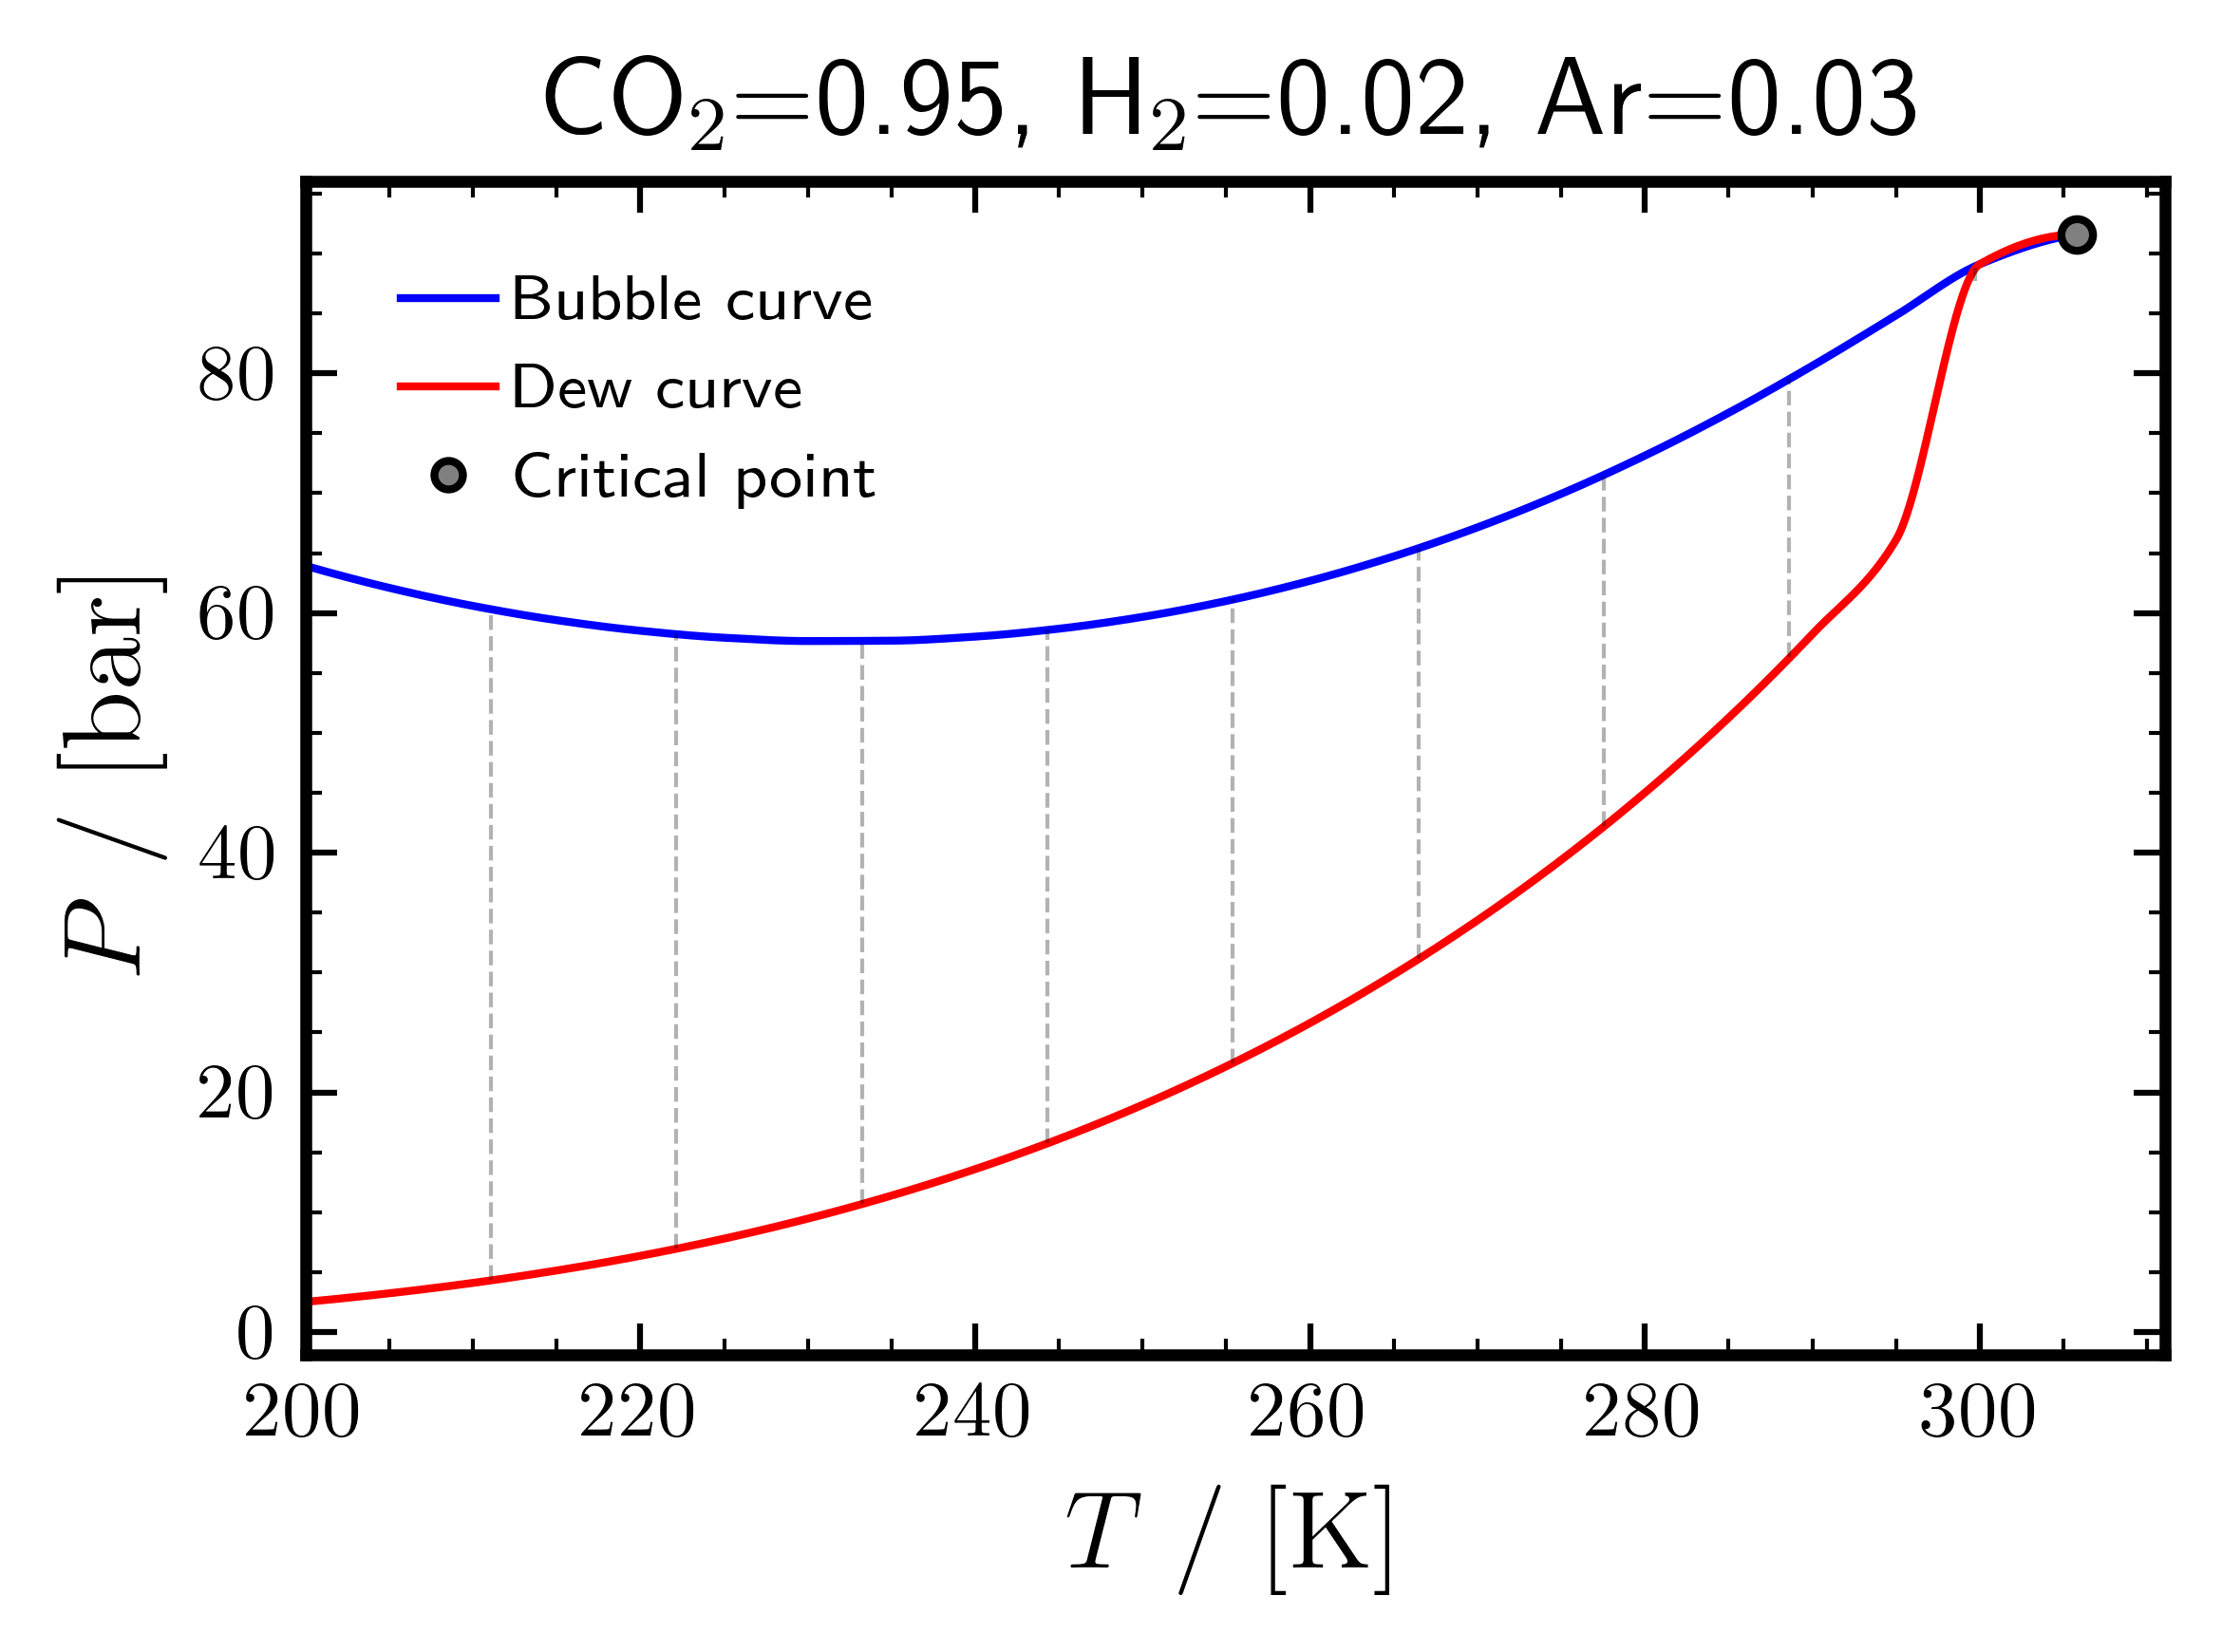

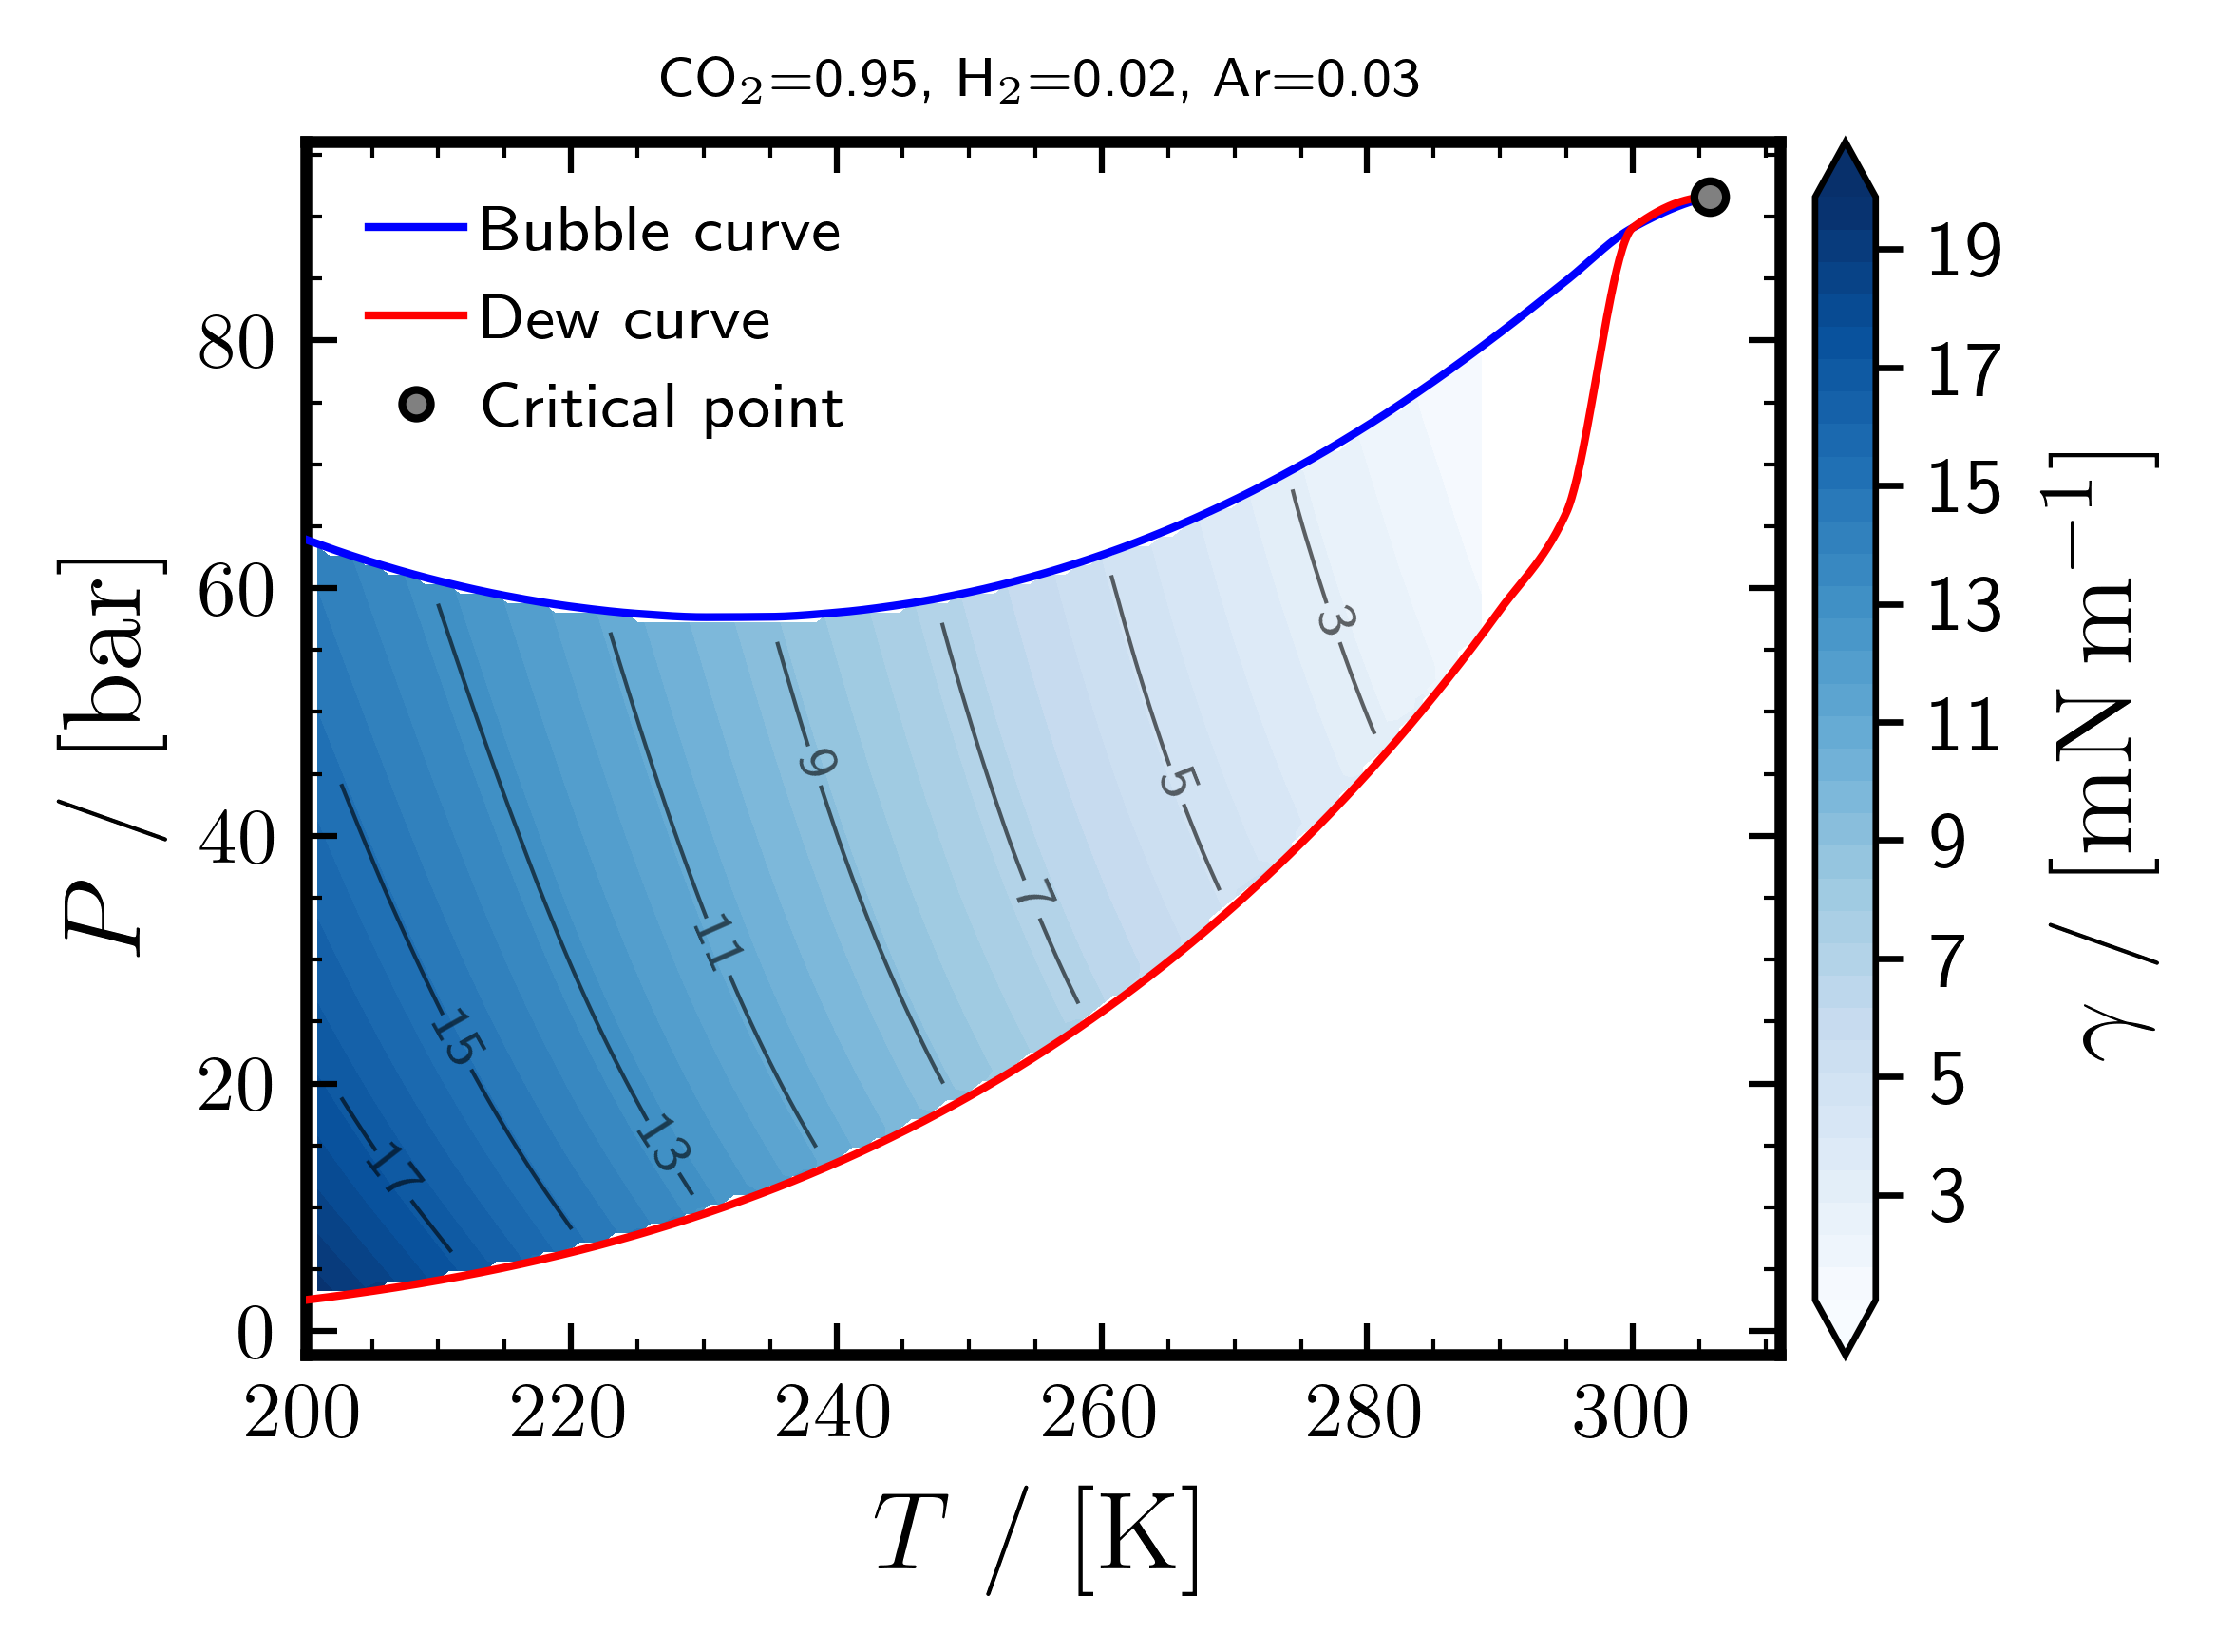

In [4]:
# --- cDFT: PT space sweep, TP flash, and planar interface IFT ---
# Uses the same N_T x N_P grid as the SEC colormaps for direct comparison.

sec_cdft = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)

for feed_key, feed in PT_results.items():

    TP_z = np.array(feed.get("z", []))
    CT   = feed["TC_K"] * si.KELVIN
    CP   = feed["PC_bar"] * si.BAR

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(TP_z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, parameters)

    # Build interpolation arrays from phase envelope (fine resolution from T_STEP=1)
    bub_pts = sorted(feed.get("bubble", []), key=lambda p: p["T_K"])
    dew_pts = sorted(feed.get("dew", []),    key=lambda p: p["T_K"])
    T_bub_arr = np.array([p["T_K"]  for p in bub_pts])
    P_bub_arr = np.array([p["P_bar"] for p in bub_pts])
    T_dew_arr = np.array([p["T_K"]  for p in dew_pts])
    P_dew_arr = np.array([p["P_bar"] for p in dew_pts])

    # Shared T grid (same as SEC uses internally)
    T_min   = max(T_bub_arr.min(), T_dew_arr.min())
    T_max   = min(T_bub_arr.max(), T_dew_arr.max()) * 0.999
    T_grid  = np.linspace(T_min, T_max, N_T)

    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bub_arr, P_bub_arr)],
            "dew_curve":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_arr, P_dew_arr)],
            "isothermal_lines": []
        },
        "interfacial_data": {}
    }

    if verbose:
        print(f"\n{feed_key}: cDFT sweep with N_T={N_T}, N_P={N_P}")

    for T_K in T_grid:
        # Interpolate bubble/dew pressures at this T
        P_b = float(np.interp(T_K, T_bub_arr, P_bub_arr))
        P_d = float(np.interp(T_K, T_dew_arr, P_dew_arr))

        if P_b <= P_d:
            continue

        T = int(round(T_K))  # integer key for storage

        VLE_DFT[feed_key]["phase_envelope"]["isothermal_lines"].append(
            {"T_K": float(T_K), "P_bubble_bar": P_b, "P_dew_bar": P_d}
        )

        # Rebuild parameters with T-dependent kij
        parameters_T = PARAMETERS(active_components, T_K=float(T_K), kij_builder=builder, model_map=active_map)
        eos_T        = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
        molar_masses = PropertyCalculator.molar_masses(parameters_T)

        # --- Pure CO2 properties at this temperature ---
        gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
            sec_cdft._pure_component_cDFT("carbon dioxide", float(T_K))

        pressures = np.linspace(P_d * 1.01, P_b * 0.99, N_P)
        ax.plot([T_K, T_K], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)

        VLE_DFT[feed_key]["interfacial_data"][T_K] = []

        for P in pressures:
            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} | z = {active_z}")

            try:
                eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                    eos_T, T_K*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
            except Exception as e:
                print(f"TP flash failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                continue

            interface = InterfacialTensionCalculator.build_planar_interface(
                eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid)

            try:
                gamma_mN_m, interfacial_thickness_nm, enrichment = \
                    InterfacialTensionCalculator.solve_interface_properties(interface)
            except Exception as e:
                print(f"IFT failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                gamma_mN_m = np.nan
                interfacial_thickness_nm = np.nan
                enrichment = tuple(np.nan for _ in active_components)

            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

            row_data = DataProcessor.assemble_row(
                T_K, P, active_z, CT, CP, P_b, P_d,
                liquid_density, vapor_density,
                x, y, gamma_mN_m, interfacial_thickness_nm,
                active_components, enrichment,
                gamma0_CO2=gamma0_CO2,
                rhoL0_CO2_mol_cm3=rhoL0_CO2,
                rhoV0_CO2_mol_cm3=rhoV0_CO2,
                Tc_CO2=Tc_CO2,
                Psat_CO2=Psat_CO2,
                ML_mode=True,
            )
            VLE_DFT[feed_key]["interfacial_data"][T_K].append(row_data)

    PlottingEngine.save_plots(fig, f"PT_{feed_key}", folder=CSV_FOLDER)

    fig_gamma = PlottingEngine.plot_interfacial_tension_map(PT_results, VLE_DFT, feed_key, parameters)
    if fig_gamma is not None:
        PlottingEngine.save_plots(fig_gamma, f"Gamma_cDFT_{feed_key}", folder=CSV_FOLDER)

summary = DataProcessor.summarize_vle_dft(VLE_DFT)
if verbose:
    print(summary)

saved_files = DataProcessor.export_to_csv(VLE_DFT, folder=CSV_FOLDER, verbose=verbose)

## Part 2: SEC IFT Colormaps (Parachor T-dependent & WSD)

In [5]:
# --- SEC: Compute PT colormap data for each feed ---
# Uses the same N_T x N_P resolution and T_grid as the cDFT sweep.

feed_key = list(PT_results.keys())[0]
feed     = PT_results[feed_key]

Tc_K   = feed["TC_K"]
Pc_bar = feed["PC_bar"]

# Extract bubble/dew arrays from PT_results
T_bub_all = [pt["T_K"]  for pt in feed["bubble"]]
P_bub_all = [pt["P_bar"] for pt in feed["bubble"]]
T_dew_all = [pt["T_K"]  for pt in feed["dew"]]
P_dew_all = [pt["P_bar"] for pt in feed["dew"]]

# Reference eos for SEC
params_ref = PARAMETERS(COMPONENTS, T_K=T_initial_guess, kij_builder=builder, model_map=KIJ_map)
eos_ref    = feos.HelmholtzEnergyFunctional.pcsaft(params_ref)

model = semi_emperical_correlations()

# --- Parachor (T-dependent) ---
data_parachor = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    n_T=N_T,
    n_P=N_P,
    recompute_parachor=True,
    kij_builder=builder,
    model_map=KIJ_map,
    T_grid=T_grid,
)

# --- WSD method (with correction) ---
data_wsd = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=True,
    n_T=N_T,
    n_P=N_P,
    kij_builder=builder,
    model_map=KIJ_map,
    T_grid=T_grid,
)

# --- WSD method (without correction) ---
data_wsd_nocorr = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=False,
    n_T=N_T,
    n_P=N_P,
    kij_builder=builder,
    model_map=KIJ_map,
    T_grid=T_grid,
)

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:239: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=299.7 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


## SEC Colormap Plots

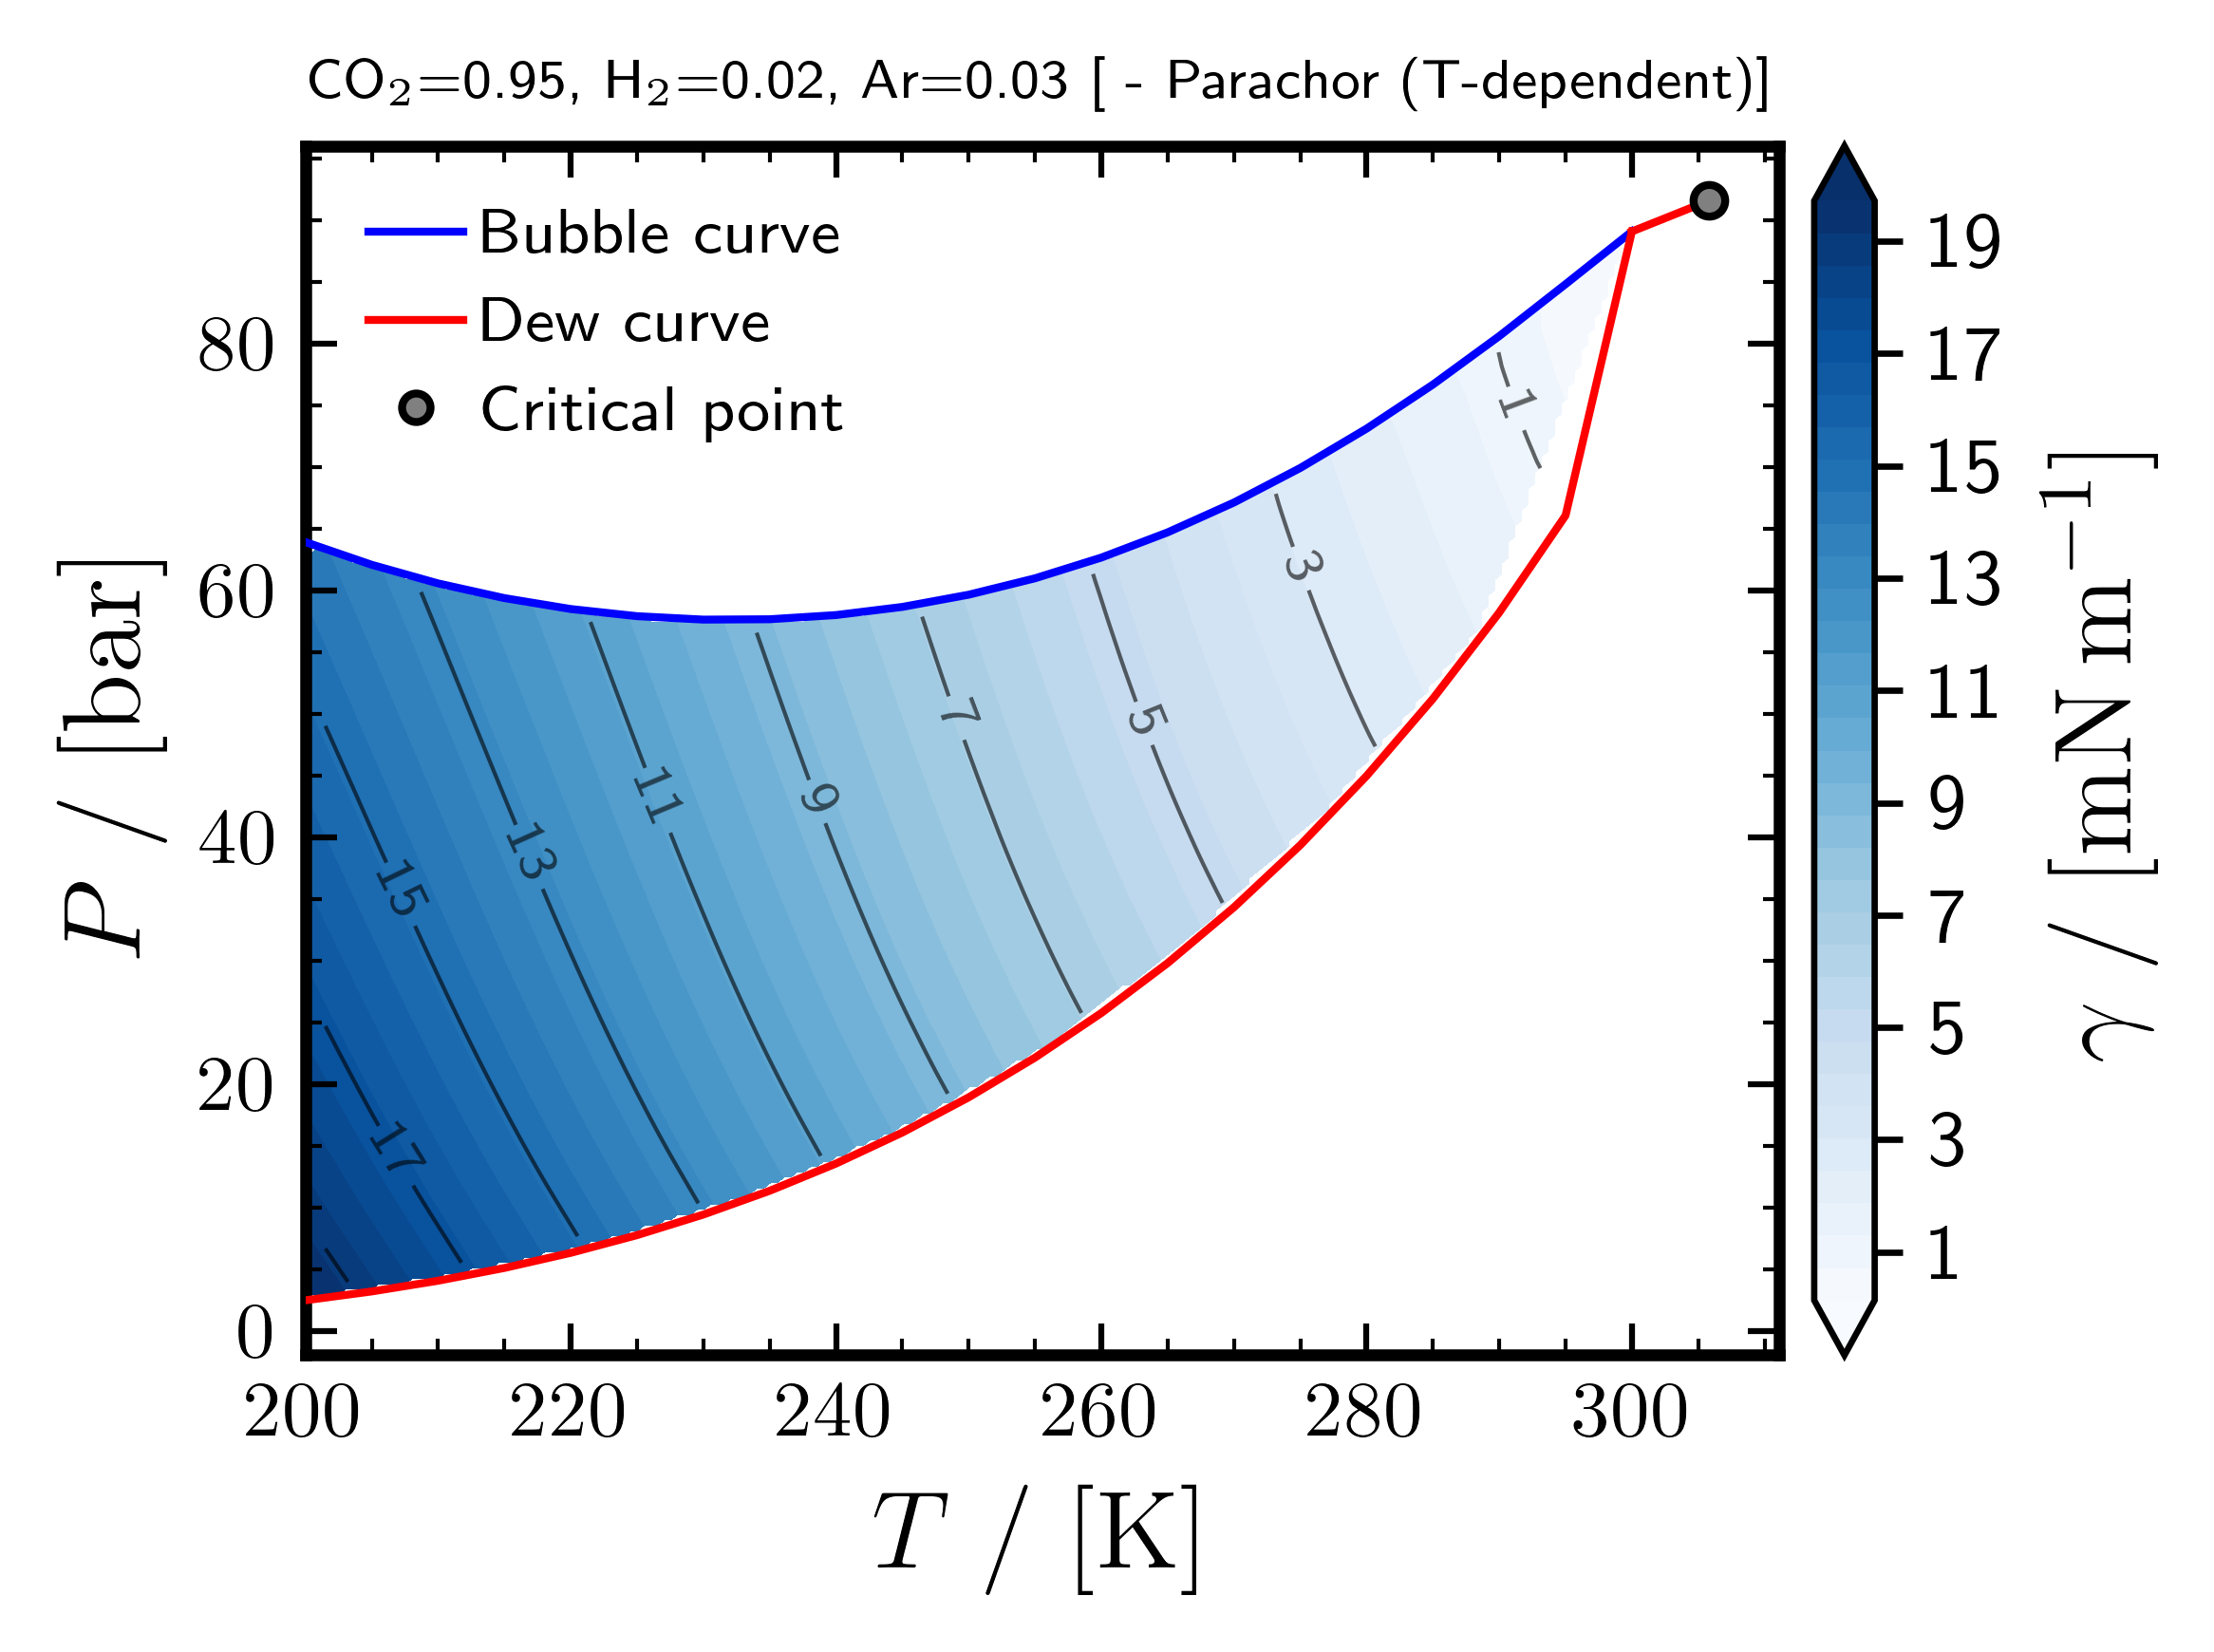

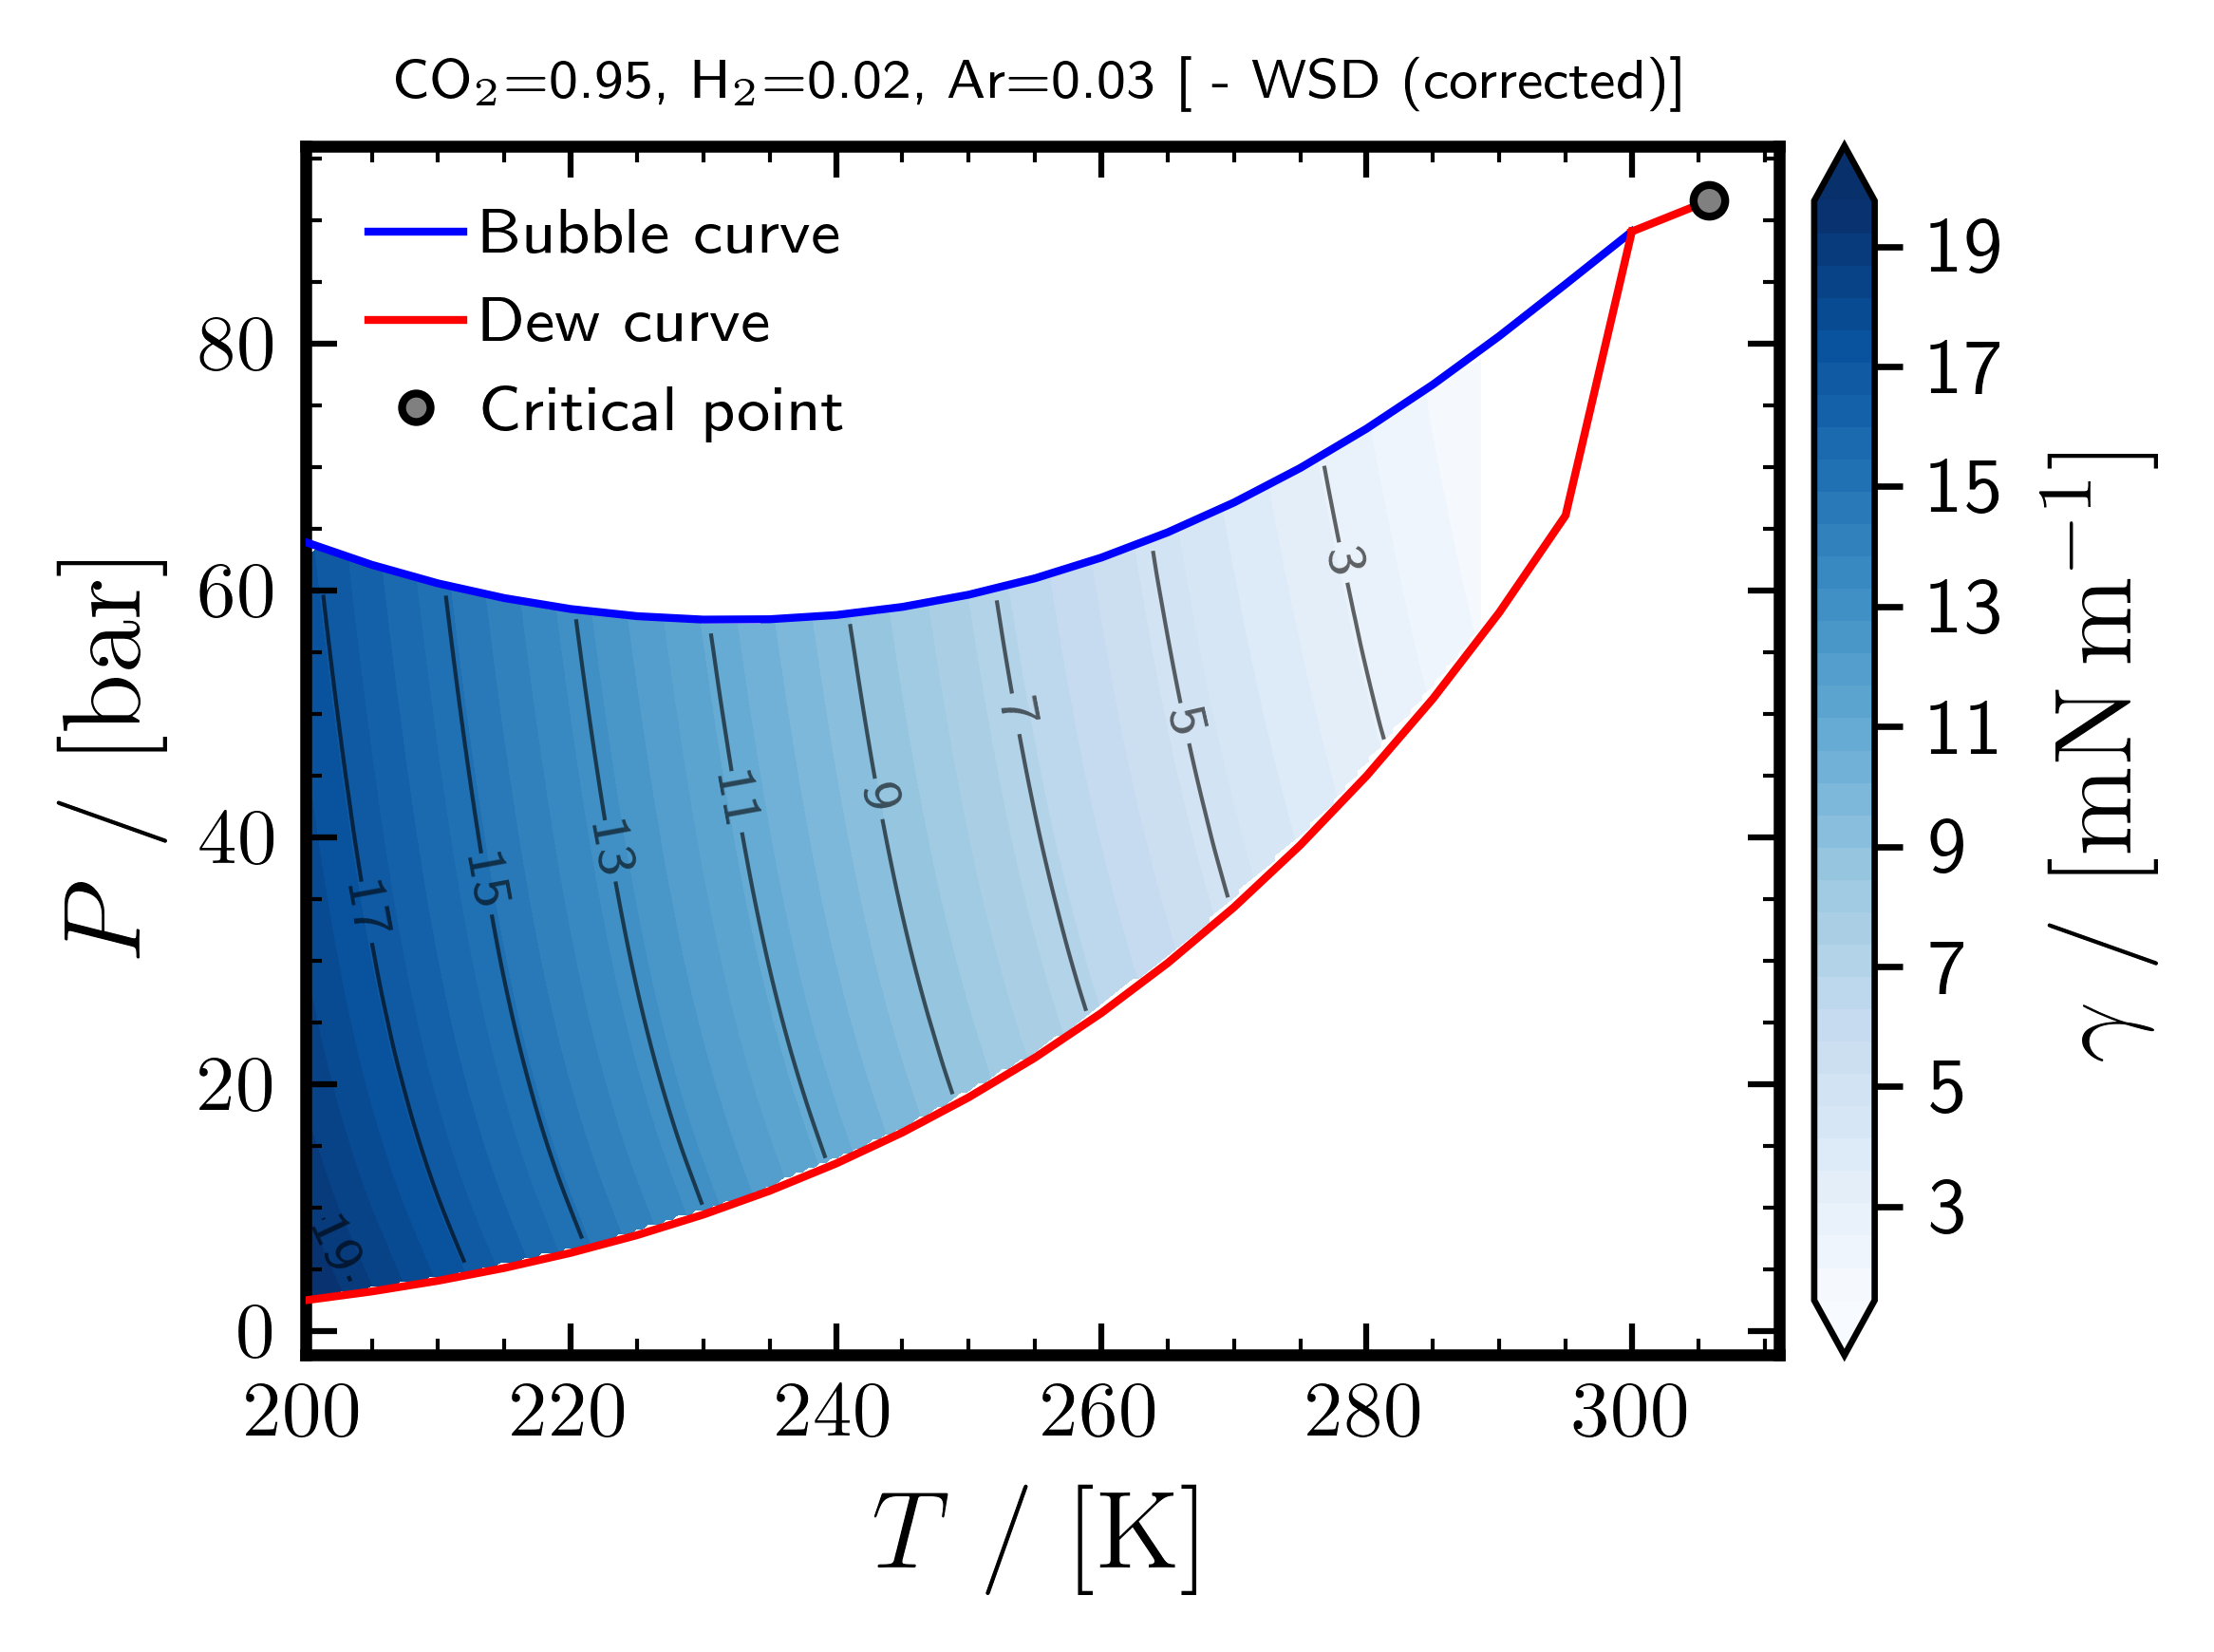

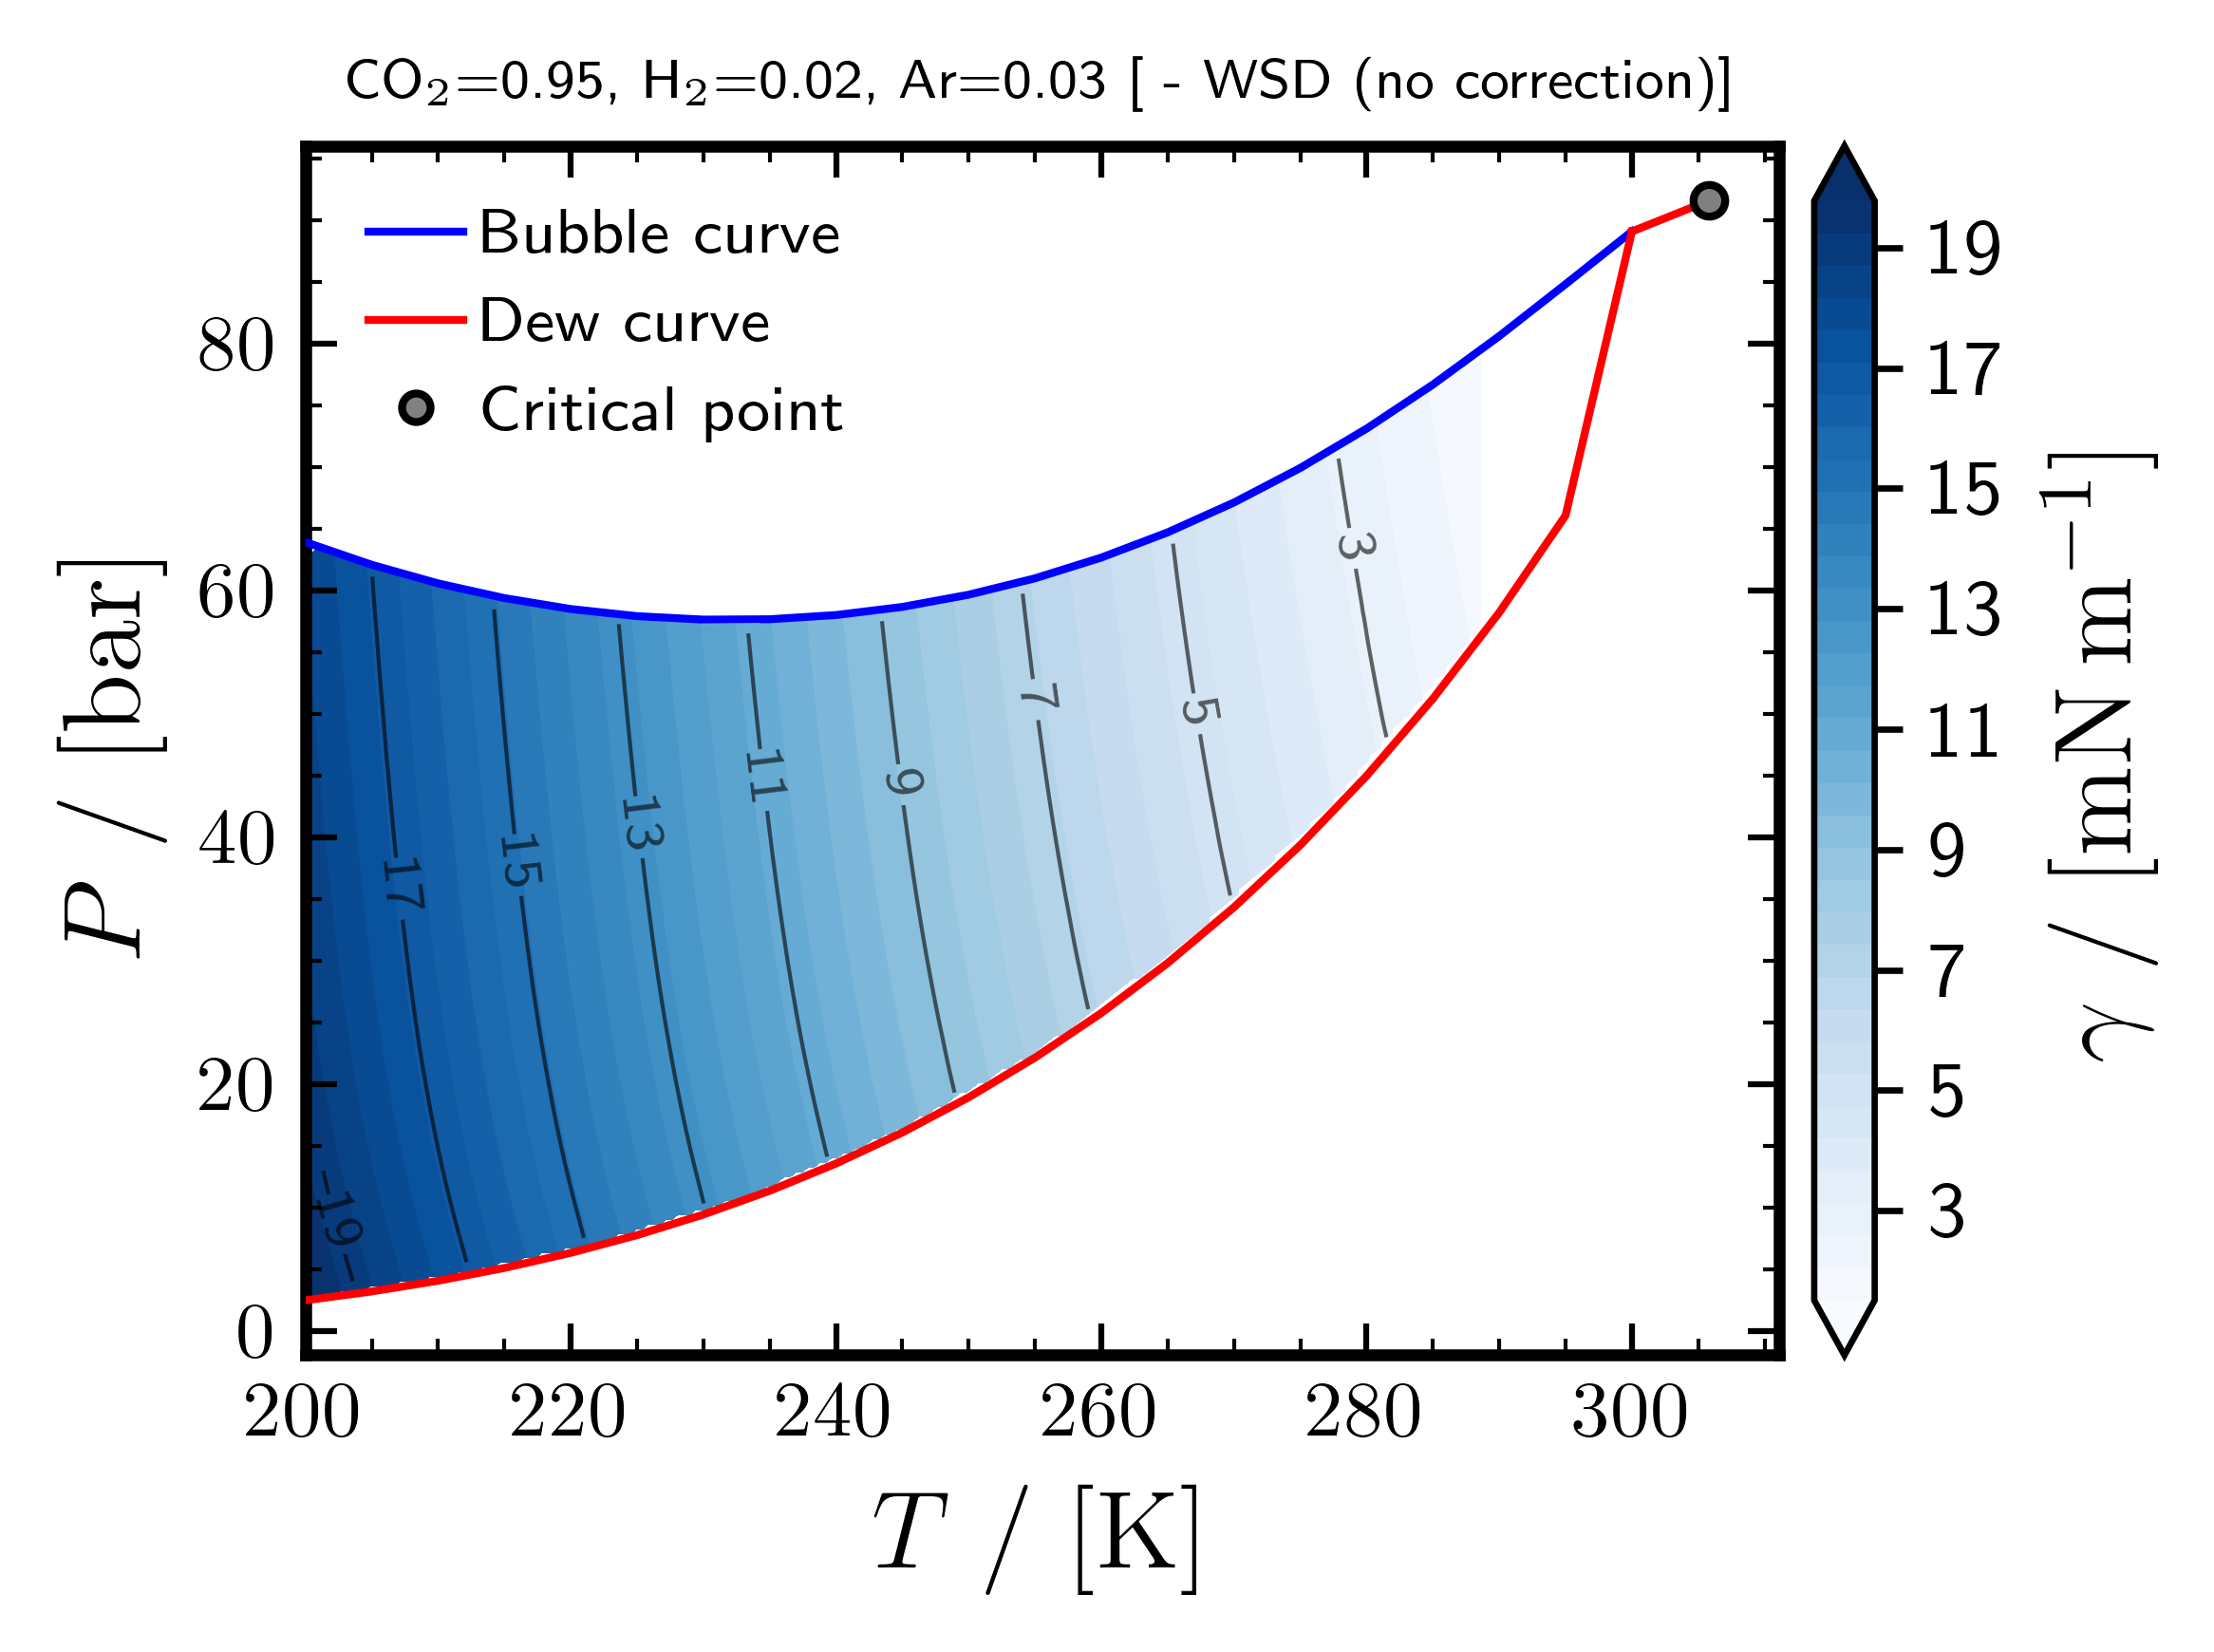

In [6]:
# --- SEC Colormap: Parachor (T-dependent) ---
fig1, ax1 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_parachor,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - Parachor (T-dependent)",
)
plt.savefig(f"{CSV_FOLDER}/PNG/colormap_parachor_Tdep.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/PDF/colormap_parachor_Tdep.pdf", bbox_inches="tight")
plt.show()

# --- SEC Colormap: WSD (with correction) ---
fig2, ax2 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_wsd,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - WSD (corrected)",
)
plt.savefig(f"{CSV_FOLDER}/PNG/colormap_wsd.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/PDF/colormap_wsd.pdf", bbox_inches="tight")
plt.show()

# --- SEC Colormap: WSD (without correction) ---
fig3, ax3 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_wsd_nocorr,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - WSD (no correction)",
)
plt.savefig(f"{CSV_FOLDER}/PNG/colormap_wsd_nocorr.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/PDF/colormap_wsd_nocorr.pdf", bbox_inches="tight")
plt.show()

## Save SEC Colormap DataFrames

In [7]:
# --- Save SEC PT colormap DataFrames ---
# Build cDFT data dict for direct merge (no interpolation)
feed_key = list(VLE_DFT.keys())[0]
T_cdft, P_cdft, G_cdft = [], [], []
for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
    for pt in data_list:
        if "gamma" in pt and not np.isnan(pt["gamma"]):
            T_cdft.append(pt["temperature"])
            P_cdft.append(pt["pressure"])
            G_cdft.append(pt["gamma"])

data_cdft = {"T": T_cdft, "P": P_cdft, "gamma": G_cdft}

dfs_PT = SEC.semi_emperical_correlations.save_PT_colormap_dataframes(
    data_parachor=data_parachor,
    data_wsd=data_wsd,
    output_dir=f"{CSV_FOLDER}/interfacial_results",
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    n_exp=3.87,
    ML_mode=True,
    main_component_index=0,
    all_components=ALL_COMPONENTS,
    data_cdft=data_cdft,
    data_wsd_nocorr=data_wsd_nocorr,
)

df_PT_para = dfs_PT["PT_parachor"]
df_PT_wsd  = dfs_PT["PT_wsd"]

print("\nParachor (T-dep) columns:", list(df_PT_para.columns))
print("WSD columns:",              list(df_PT_wsd.columns))

Saved CSV_combined_constant_feed/interfacial_results/PT_parachor.csv (100 rows, 31 cols)
Saved CSV_combined_constant_feed/interfacial_results/PT_wsd.csv (90 rows, 28 cols)

Parachor (T-dep) columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', 'rhoV2_hydrogen', 'rhoV3_argon', 'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide', 'Tc_carbon dioxide', 'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'parachor_carbon dioxide', 'parachor_hydrogen', 'parachor_argon', 'n_exp', 'gamma_parachor', 'gamma_cDFT_minus_parachor']
WSD columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', 'rho

## Difference Colormaps (cDFT vs SEC)
Compare cDFT and SEC methods using the `ColormapDifference` class:
- **cDFT - Parachor**
- **cDFT - WSD (corrected)**
- **cDFT - WSD (no correction)**

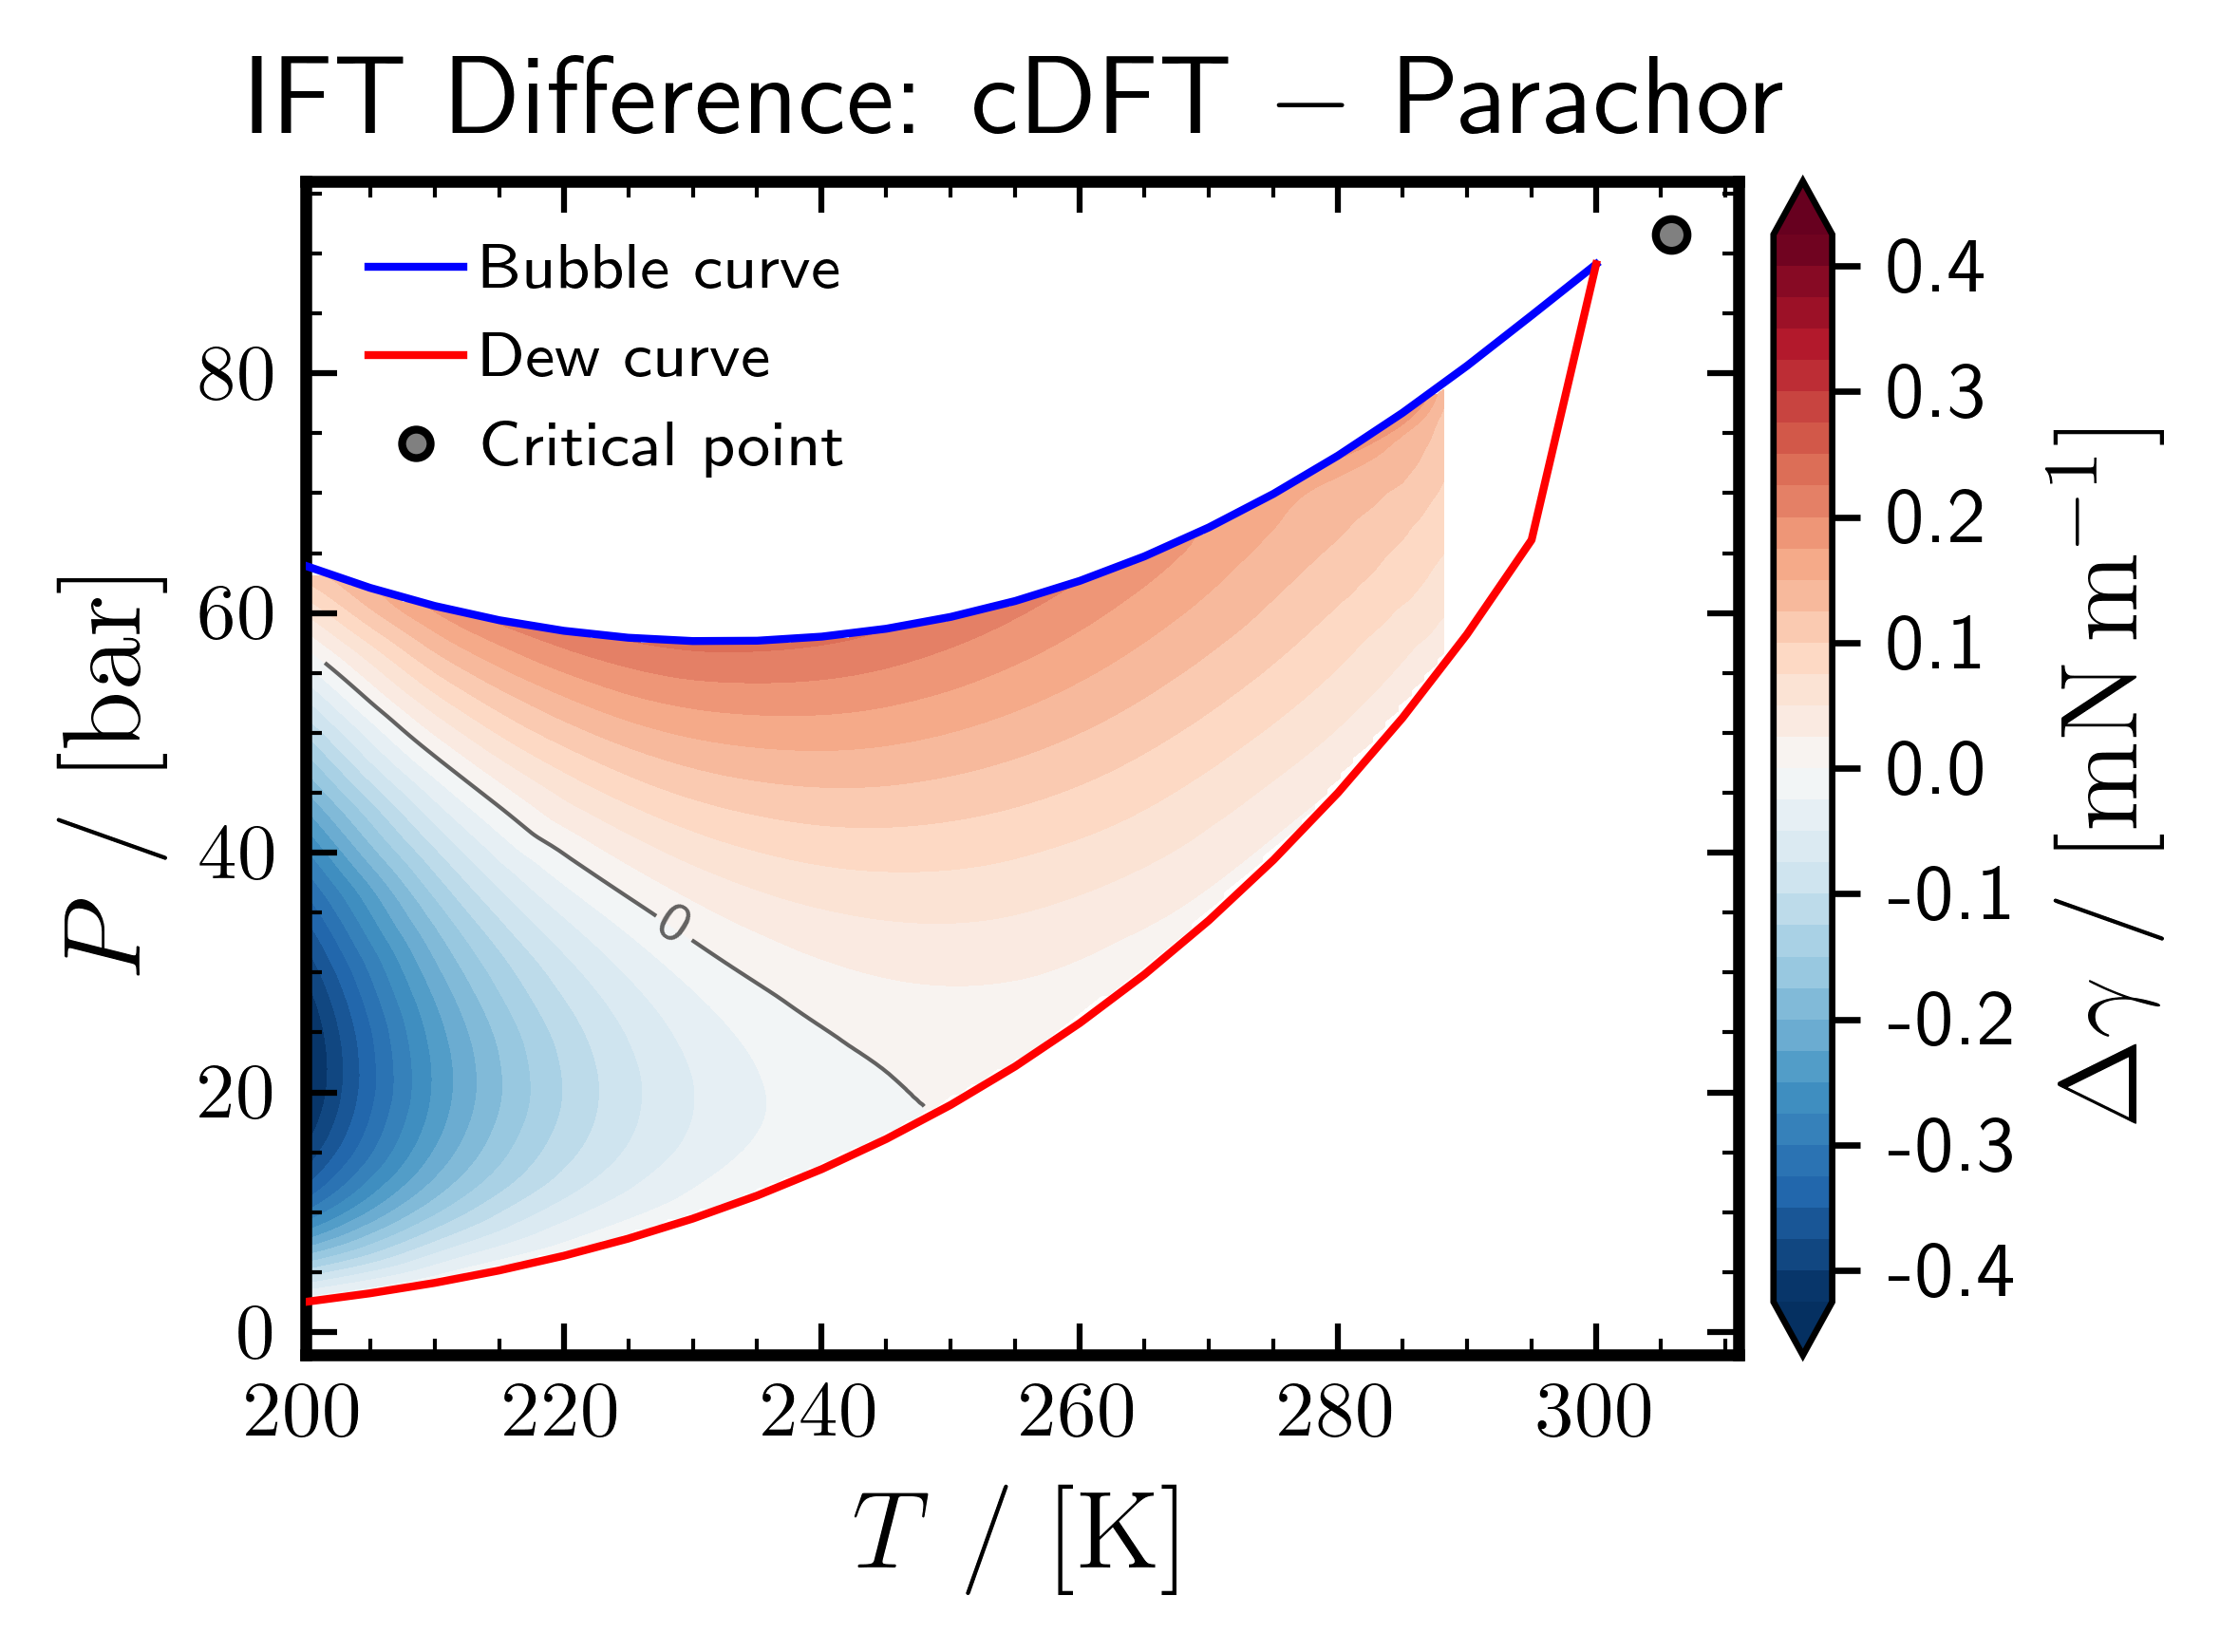

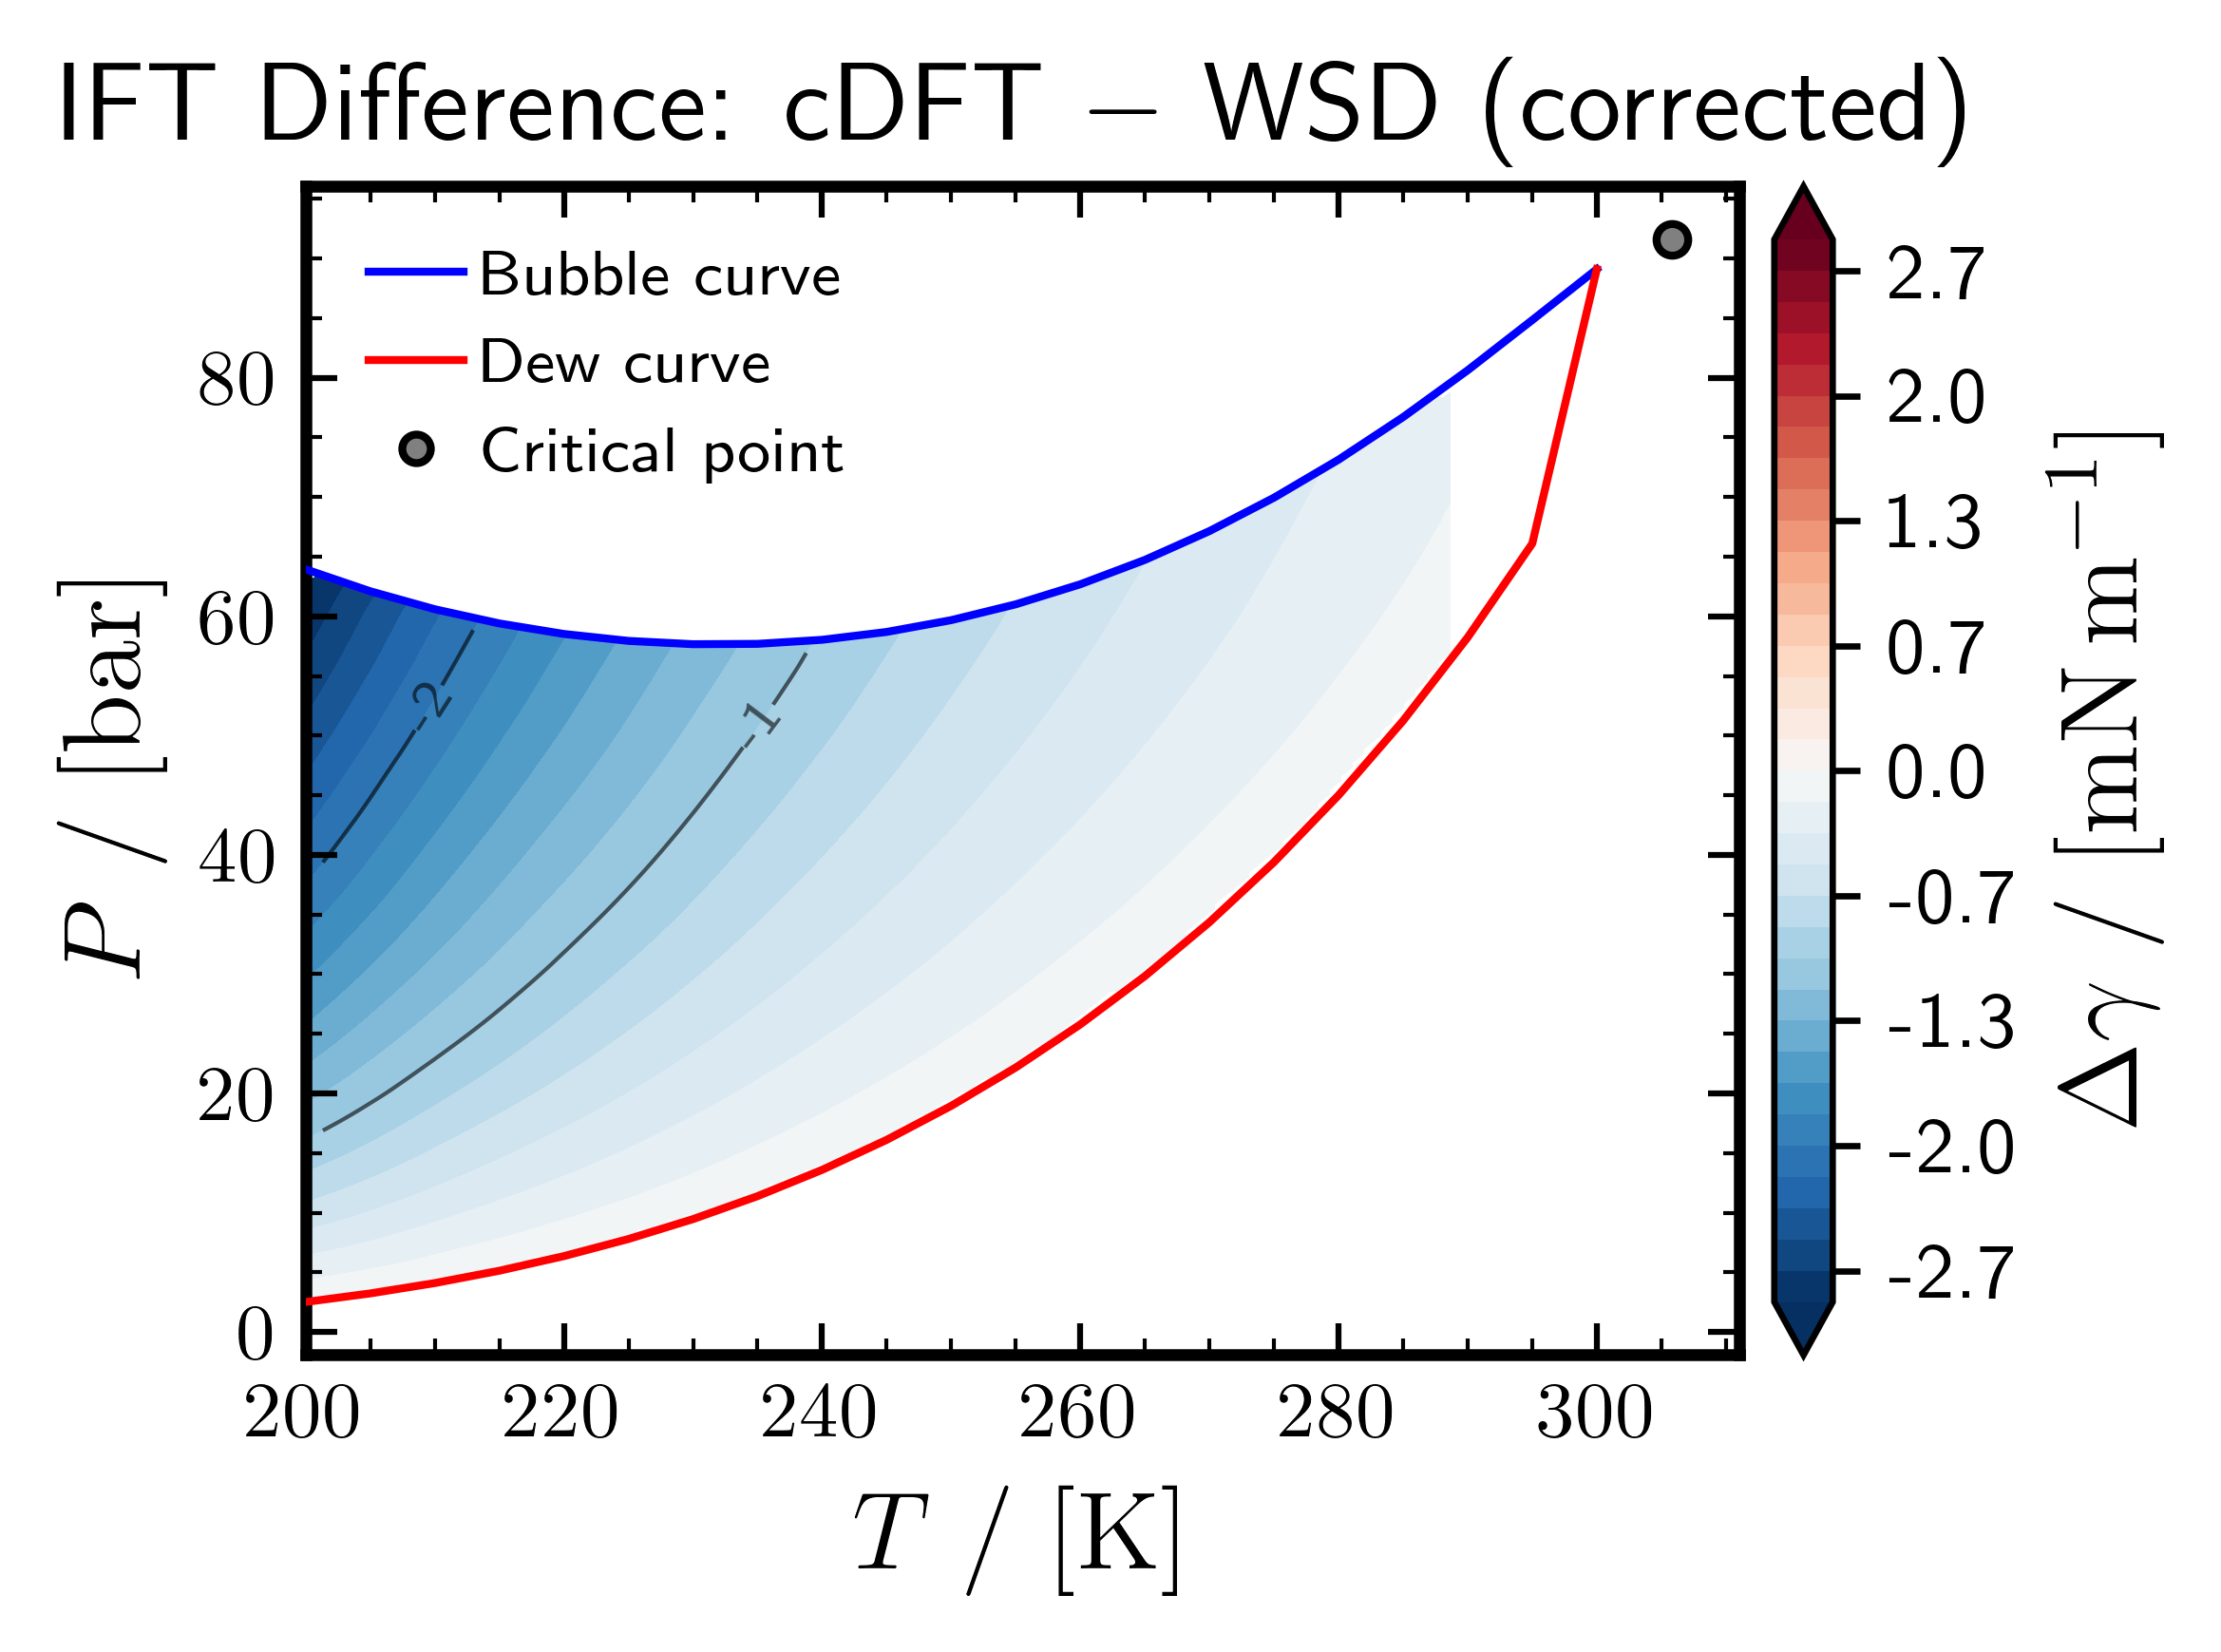

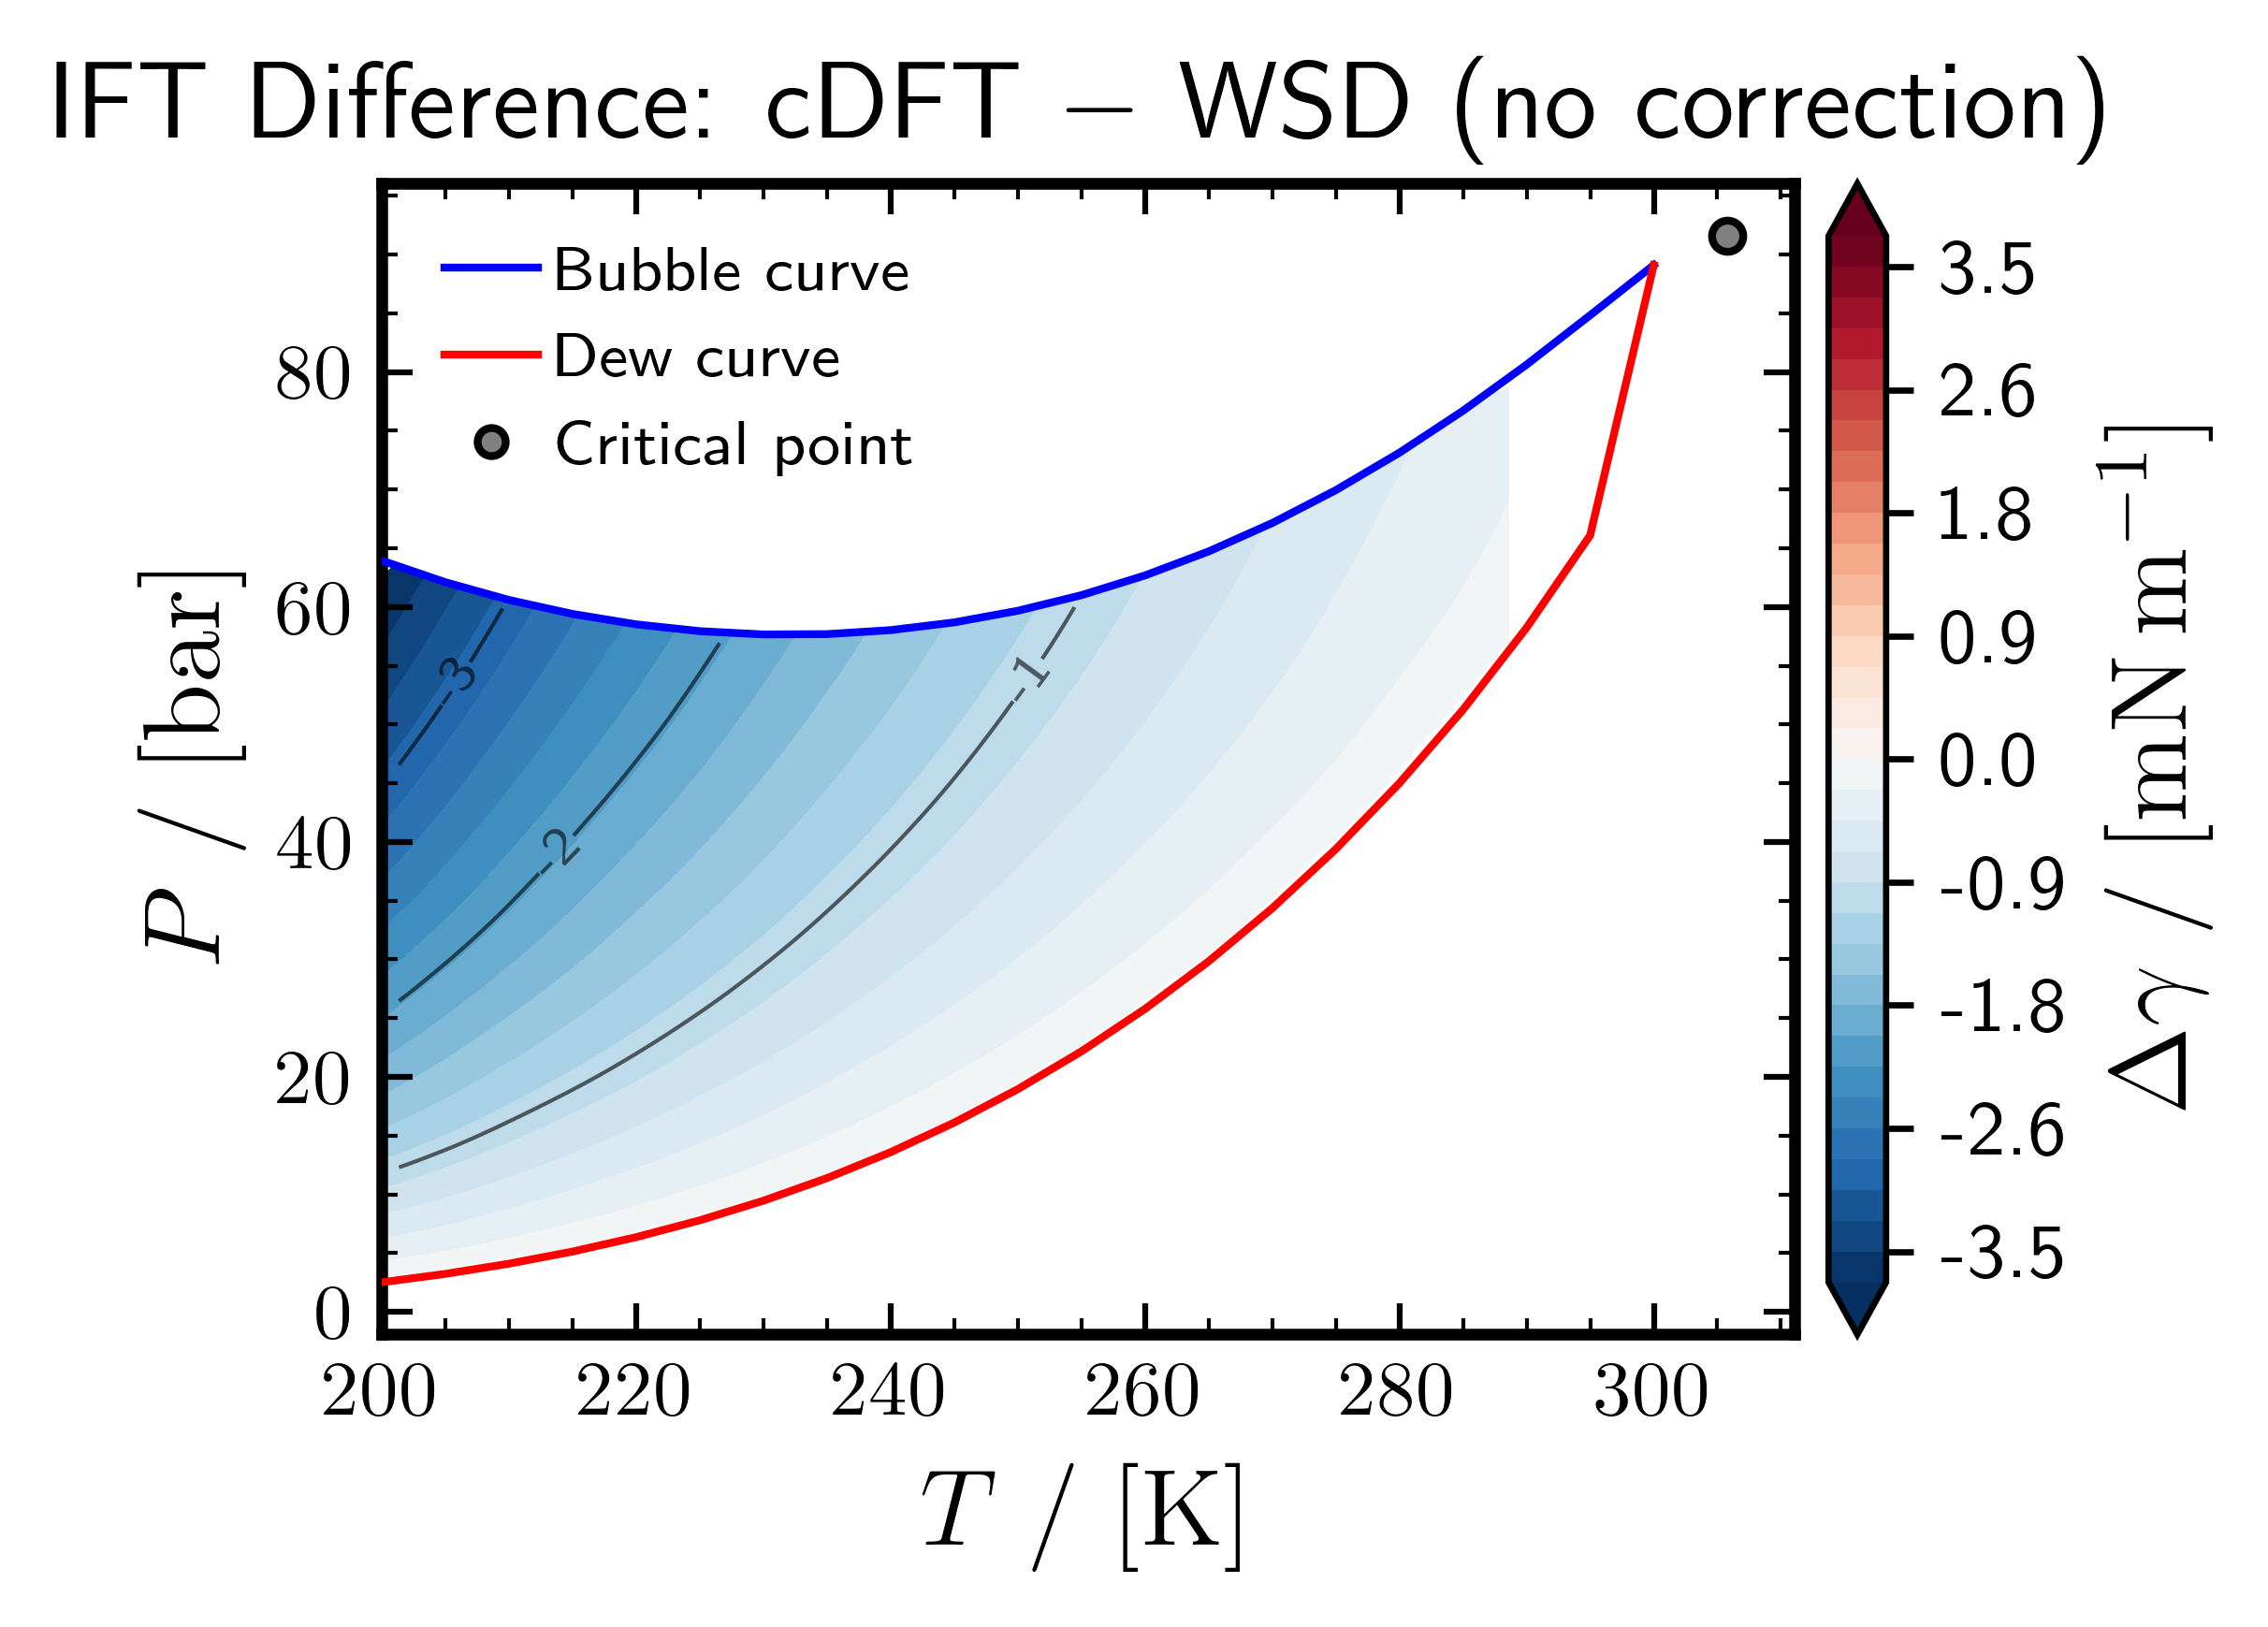

In [8]:
# --- Difference colormaps using ColormapDifference class ---
# Sign convention: diff = data_A - data_B = cDFT - SEC
#   diff > 0  -->  SEC underpredicts relative to cDFT (the reference)
#   diff < 0  -->  SEC overpredicts relative to cDFT

feed = PT_results[list(PT_results.keys())[0]]

diff_pairs = [
    ("cDFT $-$ Parachor",            data_cdft, data_parachor),
    ("cDFT $-$ WSD (corrected)",     data_cdft, data_wsd),
    ("cDFT $-$ WSD (no correction)", data_cdft, data_wsd_nocorr),
]

for label, dA, dB in diff_pairs:
    cdiff = ColormapDifference(
        data_A=dA, data_B=dB,
        T_bub=T_bub_all, P_bub=P_bub_all,
        T_dew=T_dew_all, P_dew=P_dew_all,
    )
    fig, ax = cdiff.plot(
        Tc_K=Tc_K, Pc_bar=Pc_bar,
        T_bub=T_bub_all, P_bub=P_bub_all,
        T_dew=T_dew_all, P_dew=P_dew_all,
        label=label,
        isoline_step=1,
    )
    if fig is not None:
        safe_label = label.replace(" ", "_").replace("$", "").replace("-", "minus").replace("\\", "")
        plt.savefig(f"{CSV_FOLDER}/PNG/diff_{safe_label}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{CSV_FOLDER}/PDF/diff_{safe_label}.pdf", bbox_inches="tight")
        plt.show()
    else:
        print(f"Skipping '{label}' — insufficient overlap data.")

In [9]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.67 minutes
